# Travel Planner Generator

This notebook implements an AI-powered meta-software development workflow for the DTS114TC coursework. It turns a travel planning business problem into software artefacts, including SDLC documentation, UML diagrams, a Flask API, a travel planning website, and deployment assets.

## Environment Requirements

To run this notebook, use a Python/Jupyter environment with `requests`, `python-dotenv`, `flask`, `flask-cors`, and `pytest` installed. An APIFree API key should be provided through a `.env` file or environment variable as `APIFREE_API_KEY`. The notebook checks both the project root `.env` and `Task1/.env`, so it can still run if the key file is kept beside this notebook. Internet access is required for APIFree and PlantUML diagram rendering. Docker Desktop is only required for the deployment step in Task2. The recommended submission layout is `Task1/travel_planner_generator.ipynb`, but the notebook can also run from a standalone folder and will generate `Task2` relative to the current working directory.

## Development Methodology

The project follows an AI-driven development lifecycle supported by Agile-style iteration. The workflow is organised into three phases: Inception, Construction, and Operation.

## Setup

This section prepares imports, output folders, and APIFree API configuration. The notebook requires an APIFree API key for AI generation.

In [31]:
from pathlib import Path
import json
import os

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "task1" else CURRENT_DIR
print(f"Notebook working directory: {CURRENT_DIR}")
print(f"Project output root: {PROJECT_ROOT}")
TASK2_DIR = PROJECT_ROOT / "Task2"
APP_DIR = TASK2_DIR / "app"
DOCS_DIR = TASK2_DIR / "docs"
UML_DIR = TASK2_DIR / "uml"
ASSETS_DIR = APP_DIR / "static" / "images"

for directory in [APP_DIR, DOCS_DIR, UML_DIR, ASSETS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

env_candidates = [PROJECT_ROOT / ".env", CURRENT_DIR / ".env", PROJECT_ROOT / "Task1" / ".env"]

try:
    from dotenv import load_dotenv
    loaded_env_files = []
    for env_path in env_candidates:
        if env_path.exists():
            load_dotenv(env_path, override=False)
            loaded_env_files.append(str(env_path))
    print("Loaded .env file(s): " + ", ".join(loaded_env_files) if loaded_env_files else "No .env file found; using existing environment variables only.")
except ImportError:
    print("python-dotenv is not installed. The notebook will use existing environment variables only.")

API_KEY = os.getenv("APIFREE_API_KEY")
APIFREE_BASE_URL = os.getenv("APIFREE_BASE_URL", "https://api.apifree.ai/v1")
APIFREE_MODEL = os.getenv("APIFREE_MODEL", "gpt-5-mini")
APIFREE_IMAGE_MODEL = os.getenv("APIFREE_IMAGE_MODEL", "google/nano-banana-2")

print("APIFree API key detected" if API_KEY else "APIFREE_API_KEY is not configured yet")
print(f"Text model: {APIFREE_MODEL}")
print(f"Image model: {APIFREE_IMAGE_MODEL}")

Notebook working directory: c:\Users\Qingyi Yang\Desktop\DTS114\2469447_Qingyi.Yang\Task1
Project output root: c:\Users\Qingyi Yang\Desktop\DTS114\2469447_Qingyi.Yang
Loaded .env file(s): c:\Users\Qingyi Yang\Desktop\DTS114\2469447_Qingyi.Yang\.env
APIFree API key detected
Text model: gpt-5-mini
Image model: google/nano-banana-2


# Phase 1: Inception

Inception converts the business problem into software development context, including a problem statement, personas, requirements, and user stories.

In [32]:
business_problem = """
A small travel agency needs a web application that helps tourists generate personalised city travel itineraries. Users should be able to enter a destination, trip length, budget level, and interests. The system should return a clear day-by-day itinerary and present it through both a Flask API and a website.
""".strip()

project_context = {
    "project_name": "Travel Planner Generator",
    "business_problem": business_problem,
    "demo_destination": "Kyoto",
    "demo_days": 3,
    "demo_budget": "medium",
    "demo_interests": ["culture", "food", "nature"],
}

print(project_context["business_problem"])

A small travel agency needs a web application that helps tourists generate personalised city travel itineraries. Users should be able to enter a destination, trip length, budget level, and interests. The system should return a clear day-by-day itinerary and present it through both a Flask API and a website.


## Generated SDLC Documentation

This section uses the APIFree API to create the problem statement, personas, requirements, PRD, and user stories.

In [33]:
def generate_text(task_name, prompt, context):
    """Generate text with the APIFree chat endpoint."""
    api_key = os.getenv("APIFREE_API_KEY")
    base_url = os.getenv("APIFREE_BASE_URL", "https://api.apifree.ai/v1")
    model = os.getenv("APIFREE_MODEL", "gpt-5-mini")

    if not api_key:
        raise RuntimeError("APIFREE_API_KEY is not configured. Add it to the environment before running this notebook.")

    import requests

    response = requests.post(
        f"{base_url.rstrip('/')}/chat/completions",
        headers={
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json",
        },
        json={
            "model": model,
            "messages": [
                {"role": "system", "content": "You are a software engineering assistant producing concise coursework artefacts."},
                {"role": "user", "content": prompt},
            ],
            "temperature": 0.3,
        },
        timeout=180,
    )
    response.raise_for_status()
    data = response.json()
    if "error" in data:
        message = data["error"].get("message", data["error"])
        raise RuntimeError(f"APIFree generation failed for {task_name}: {message}")
    if "choices" not in data:
        raise RuntimeError(f"APIFree response for {task_name} did not include choices: {data}")
    return data["choices"][0]["message"]["content"].strip()

In [34]:
problem_statement_prompt = f"""
Given the business problem below, write one concise software engineering problem statement.

Business problem:
{business_problem}
""".strip()

personas_prompt = f"""
Generate 3-4 concise user personas for this software project.
Each persona should include the user's role, goal, and main concern.

Business problem:
{business_problem}
""".strip()

requirements_prompt = f"""
Write functional and non-functional requirements for this project in markdown.
Keep the scope suitable for a coursework Flask API and website.

Business problem:
{business_problem}
""".strip()

prd_prompt = f"""
Write a concise Product Requirements Document for this project with headings:
Overview, Goals, Scope, Constraints, Success Criteria.

Business problem:
{business_problem}
""".strip()

user_stories_prompt = f"""
Return only valid JSON for 3-5 Agile user stories using this schema:
{{
  "user_stories": [
    {{
      "id": "US1",
      "role": "...",
      "goal": "...",
      "benefit": "...",
      "acceptance_criteria": ["...", "..."]
    }}
  ]
}}

Business problem:
{business_problem}
""".strip()

generated_docs = {
    "problem_statement": generate_text("problem_statement", problem_statement_prompt, project_context),
    "personas": generate_text("personas", personas_prompt, project_context),
    "requirements": generate_text("requirements", requirements_prompt, project_context),
    "prd": generate_text("prd", prd_prompt, project_context),
    "user_stories": generate_text("user_stories", user_stories_prompt, project_context),
}

for name, content in generated_docs.items():
    suffix = "json" if name == "user_stories" else "md"
    output_path = DOCS_DIR / f"{name}.{suffix}"
    output_path.write_text(content, encoding="utf-8")
    print(f"Saved {output_path.relative_to(PROJECT_ROOT)}")

Saved Task2\docs\problem_statement.md
Saved Task2\docs\personas.md
Saved Task2\docs\requirements.md
Saved Task2\docs\prd.md
Saved Task2\docs\user_stories.json


In [35]:
print("Problem statement:\n")
print(generated_docs["problem_statement"])

print("\nUser stories preview:\n")
print(generated_docs["user_stories"][:800])

Problem statement:

Problem statement: Design and implement a full‑stack web application with a Flask REST API and responsive website that generates clear, personalized day‑by‑day city travel itineraries from user inputs (destination, trip length, budget level, and interests) by aggregating POI, opening‑hours, travel‑time and cost data, respecting temporal and budget constraints, allowing user adjustments, and meeting non‑functional goals for usability, performance, security, and maintainability.

User stories preview:

{
  "user_stories": [
    {
      "id": "US1",
      "role": "Tourist",
      "goal": "Enter a destination, trip length, budget level, and interests to generate a personalised day-by-day travel itinerary.",
      "benefit": "Quickly obtain a clear, relevant plan that saves planning time and matches personal preferences.",
      "acceptance_criteria": [
        "Given valid inputs (destination, trip length >=1, budget in {low,medium,high}, interests list non-empty), the 

# Phase 2: Construction

Construction will generate UML diagrams, Flask API code, website code, and an automatically generated destination image.

## Generated UML and Application Code

This section generates UML diagrams from the SDLC documentation and renders them through the public PlantUML server.

In [36]:
import re
import zlib
from urllib.parse import quote


def extract_plantuml(text):
    """Extract PlantUML code from a model response."""
    fenced_match = re.search(r"```(?:plantuml|puml)?\s*(.*?)```", text, re.DOTALL | re.IGNORECASE)
    if fenced_match:
        text = fenced_match.group(1).strip()
    start = text.find("@startuml")
    end = text.find("@enduml")
    if start == -1 or end == -1:
        raise ValueError("The generated UML response does not contain @startuml and @enduml.")
    return text[start:end + len("@enduml")].strip()


def plantuml_encode(text):
    """Encode PlantUML text for the PlantUML server."""
    data = zlib.compress(text.encode("utf-8"))[2:-4]
    alphabet = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz-_"

    def encode_3bytes(bytes_chunk):
        if len(bytes_chunk) < 3:
            bytes_chunk += b"\x00" * (3 - len(bytes_chunk))
        b1, b2, b3 = bytes_chunk
        c1 = b1 >> 2
        c2 = ((b1 & 0x3) << 4) | (b2 >> 4)
        c3 = ((b2 & 0xF) << 2) | (b3 >> 6)
        c4 = b3 & 0x3F
        return alphabet[c1] + alphabet[c2] + alphabet[c3] + alphabet[c4]

    return "".join(encode_3bytes(data[i:i + 3]) for i in range(0, len(data), 3))


def render_plantuml_png(plantuml_text, output_path):
    """Render a PlantUML diagram to PNG using the public PlantUML server."""
    import requests

    encoded = plantuml_encode(plantuml_text)
    url = f"https://www.plantuml.com/plantuml/png/{encoded}"
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    output_path.write_bytes(response.content)
    return url

In [37]:
uml_context = "\n\n".join([
    "Business Problem:\n" + business_problem,
    "Problem Statement:\n" + generated_docs["problem_statement"],
    "Requirements:\n" + generated_docs["requirements"],
    "User Stories:\n" + generated_docs["user_stories"],
])

uml_prompts = {
    "use_case_diagram": f"""
Generate a UML use case diagram in valid PlantUML for the Travel Planner Generator.
Include actors such as Tourist and Travel Agency Assistant.
Include use cases for entering preferences, generating an itinerary, viewing the website, requesting a destination image, and accessing the API.
Return only PlantUML code from @startuml to @enduml.

{uml_context}
""".strip(),
    "sequence_diagram": f"""
Generate a UML sequence diagram in valid PlantUML for the main user journey.
Show the User submitting travel preferences to the Website, the Website calling the Flask API, the Flask API calling APIFree, and the Website displaying the generated itinerary and image.
Return only PlantUML code from @startuml to @enduml.

""".strip(),
}

generated_uml = {}
for diagram_name, prompt in uml_prompts.items():
    print(f"Generating {diagram_name}...")
    uml_response = generate_text(diagram_name, prompt, project_context)
    plantuml_text = extract_plantuml(uml_response)
    generated_uml[diagram_name] = plantuml_text

    puml_path = UML_DIR / f"{diagram_name}.puml"
    png_path = UML_DIR / f"{diagram_name}.png"
    puml_path.write_text(plantuml_text, encoding="utf-8")
    render_url = render_plantuml_png(plantuml_text, png_path)

    print(f"Saved {puml_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved {png_path.relative_to(PROJECT_ROOT)}")
    print(f"Rendered with {render_url}\n")

Generating use_case_diagram...
Saved Task2\uml\use_case_diagram.puml
Saved Task2\uml\use_case_diagram.png
Rendered with https://www.plantuml.com/plantuml/png/XPF1Rjim38RlUWeYbtM0Kz-B8cYm5KLE2zfakmmO69knXSgoAzBjZABlFjfp53SfjejjaRy-_XJb6nOCqbREEDeBI0t15gL0RWDbOcjl-D7w1WDMq63sY0KzIES8-ZJwmf4nc4aTO5EtmRACgzacu3CvM1RaimwMp9f3BpD0FgwCYPYuO-tGUmfmH_f4PStWrG2qJ1coocwzQ7OTQ4z1sSG__KLEBDPZxpU173jEODVc1Ka2jfThcZyFfRTVVWs0AN6iHB1IY7w5haTYDzzrStr1euxWnKe9OYjITbQpaYMWvwOE4ia7q1J-tT8B_A0TMo75gfMczcoV2RQh1EXt3qYRe3OZPbHFAVVqr6eJyFNOAAmg7OOYzoHPcKhPLZkFraNCa9z2bfcUbfx-UgMxrjyUDf1YOrDxw3g1kzlJMFfgyxU8rAtcpPXFi1o67CWDLhYq3Pln0i1ylfXsSHBk4IUXlmCnyLQyZv-5Uy9Py51DlMsrrw7Xz_QE8hYyFFBX2gwlhSzSczDYOM9urCIxSIPJ6_yHVL1ocCa_MHyfp0tvNF_HFm00

Generating sequence_diagram...
Saved Task2\uml\sequence_diagram.puml
Saved Task2\uml\sequence_diagram.png
Rendered with https://www.plantuml.com/plantuml/png/TP9DQm8n48Rl-HM3fnQwAANqi8UY84BfGK5BBxtCxeuIcWtBP5QGudytiPireNYQ3sQUlFEIkHDawLkZEXzrhJkq0f-EE6jyKUMqKDQRh0ow7rXitYU03g

In [38]:
for diagram_name, plantuml_text in generated_uml.items():
    print(f"--- {diagram_name} ---")
    print(plantuml_text[:800])
    print()

--- use_case_diagram ---
@startuml
left to right direction
skinparam packageStyle rectangle

actor Tourist
actor "Travel Agency Assistant" as Assistant

rectangle "Travel Planner Generator" {
  usecase "Enter Preferences\n(destination, days, budget, interests)" as UC_Enter
  usecase "Generate Itinerary\n(day-by-day plan with times, cost, transport)" as UC_Generate
  usecase "View Website\n(responsive UI, export/print)" as UC_Website
  usecase "Request Destination Image\n(fetch/thumbnail)" as UC_Image
  usecase "Access API\n(POST /api/itinerary, GET /api/itinerary/{id})" as UC_API
}

' Actor relationships
Tourist --> UC_Website
Tourist --> UC_API
Tourist --> UC_Enter

Assistant --> UC_Enter
Assistant --> UC_API
Assistant --> UC_Website

' Use case relationships
UC_Website ..> UC_Enter : <<include>>
UC_Enter ..> UC_

--- sequence_diagram ---
@startuml
participant User
participant Website
participant "Flask API" as FlaskAPI
participant "APIFree" as APIFree

User -> Website: Submit travel 

Displaying Task2\uml\use_case_diagram.png


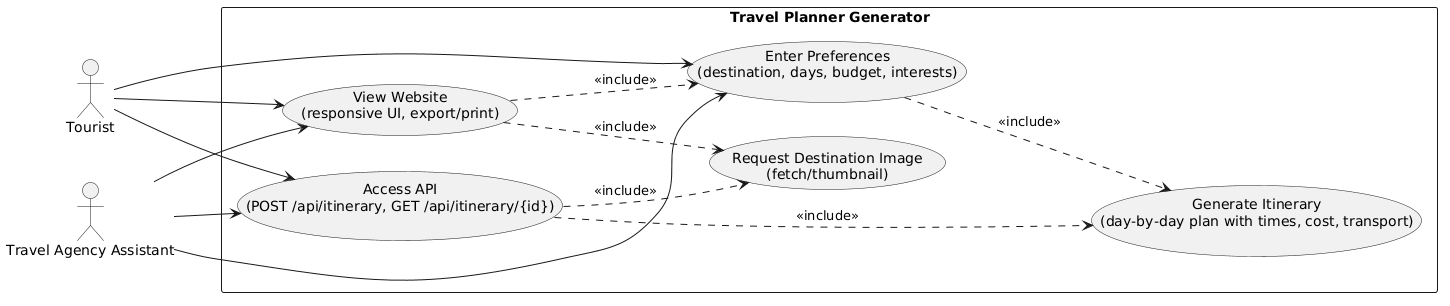

Displaying Task2\uml\sequence_diagram.png


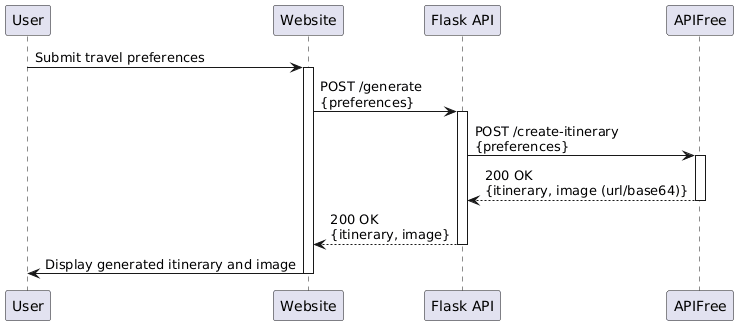

In [39]:
from IPython.display import Image, display

for diagram_name in generated_uml:
    png_path = UML_DIR / f"{diagram_name}.png"
    print(f"Displaying {png_path.relative_to(PROJECT_ROOT)}")
    display(Image(filename=str(png_path)))

## Generated Flask API

This section generates a functional Flask API for the travel planner. The generated API is saved into `Task2/app`.

In [40]:
def extract_code_block(text, language=None):
    """Extract code from a fenced markdown block, or return the raw text."""
    if language:
        pattern = rf"```{language}\s*(.*?)```"
        match = re.search(pattern, text, re.DOTALL | re.IGNORECASE)
        if match:
            return match.group(1).strip()

    match = re.search(r"```(?:\w+)?\s*(.*?)```", text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return text.strip()


flask_api_prompt = f"""
Generate a compact Python Flask application for a travel itinerary planner.
Return only Python code, with no markdown explanation.

Required behaviour:
- Use Flask and flask_cors.CORS.
- Provide GET /health returning JSON with status ok.
- Provide GET / returning a short JSON description of the API.
- Provide POST /api/itinerary accepting JSON fields: destination, days, budget, interests, travel_style.
- Validate that destination is provided and days is an integer between 1 and 14.
- Return a JSON itinerary with destination, days, budget, interests, travel_style, overview, itinerary, and tips.
- The itinerary list should contain one item per day, each with day, morning, afternoon, evening, and budget_note.
- Normalise interests before planning: map nature/outdoors to outdoor, museum to museums, history to culture, dining to food, and use culture/food/outdoor as defaults if no valid interest is provided.
- Every generated day must include at least one morning, afternoon, or evening activity.
- Support any destination string entered by the user; do not restrict the API to a fixed list of cities.
- It is acceptable to use generic travel-planning templates when real destination data is unavailable.
- Do not call external travel APIs inside the generated Flask app.
- Keep the code under 140 lines.
- Include an if __name__ == '__main__' block running on host 0.0.0.0 and port from the PORT environment variable, default 5000.

Project context:
{uml_context}
""".strip()

flask_code_response = generate_text("flask_api", flask_api_prompt, project_context)
flask_code = extract_code_block(flask_code_response, "python")

app_py_path = APP_DIR / "app.py"
app_py_path.write_text(flask_code, encoding="utf-8")
print(f"Saved {app_py_path.relative_to(PROJECT_ROOT)}")

requirements_text = """Flask==2.3.3
flask-cors==4.0.0
requests==2.31.0
"""
requirements_path = APP_DIR / "requirements.txt"
requirements_path.write_text(requirements_text, encoding="utf-8")
print(f"Saved {requirements_path.relative_to(PROJECT_ROOT)}")

Saved Task2\app\app.py
Saved Task2\app\requirements.txt


In [41]:
print(flask_code[:1200])

from flask import Flask, request, jsonify
from flask_cors import CORS
import os, datetime, hashlib

app = Flask(__name__)
CORS(app)

INTEREST_MAP = {
    'nature': 'outdoor', 'outdoors': 'outdoor', 'outdoor': 'outdoor',
    'museum': 'museums', 'museums': 'museums',
    'history': 'culture', 'culture': 'culture',
    'dining': 'food', 'food': 'food', 'restaurants': 'food',
    'nightlife': 'food'
}
DEFAULT_INTERESTS = ['culture', 'food', 'outdoor']

TEMPLATES = {
    'museums': [
        ("City Museum", "Explore local art and historical exhibits."),
        ("Contemporary Gallery", "Modern art installations and rotating shows.")
    ],
    'culture': [
        ("Historic Quarter Walk", "Guided or self-led stroll through old town."),
        ("Local History Site", "Landmark with cultural exhibits.")
    ],
    'food': [
        ("Local Market", "Taste street foods and local specialties."),
        ("Recommended Bistro", "Casual meal at a popular local spot.")
    ],
    'outdoor': [
   

## Generated Website Frontend

This section follows the Week 10 practical style by generating a single `index.html` file that is served by the Flask app and integrated with the generated API.

In [42]:
html_prompt = f"""
Generate a complete, production-ready HTML5 webpage for a Travel Planner Generator.
Return only the complete HTML document, with no markdown explanation.

Requirements:
- Use a single HTML file with inline CSS and inline JavaScript.
- Build a polished travel-planning interface, not a marketing landing page.
- Include a form with fields: destination, days, budget, interests, and travel_style.
- Use Fetch API to send POST requests to /api/itinerary as JSON.
- Display destination, overview, day-by-day itinerary, budget notes, and tips from the API response.
- Render each day using the API's morning, afternoon, and evening fields when an activities array is not present.
- Include a visible, spacious image showcase for AI-generated travel imagery. The default website image should stay visible while a separate destination image appears after generation. Avoid placing images inside tiny header icons or overlapping text.
- Include helpful loading, success, and error states.
- Keep all text concise and professional.
- Do not use external images or map APIs.
- The page must work when served by Flask from the same folder as app.py.

API contract:
POST /api/itinerary accepts JSON fields destination, days, budget, interests, travel_style.
The API returns JSON with destination, days, budget, interests, travel_style, overview, itinerary, and tips.

Project context:
{uml_context}
""".strip()

html_response = generate_text("website_frontend", html_prompt, project_context)
html_code = extract_code_block(html_response, "html")

index_path = APP_DIR / "index.html"
index_path.write_text(html_code, encoding="utf-8")
print(f"Saved {index_path.relative_to(PROJECT_ROOT)}")


Saved Task2\app\index.html


In [43]:
def ensure_flask_serves_index(app_path):
    """Update the generated Flask app so GET / serves index.html like the Week 10 practical."""
    code = app_path.read_text(encoding="utf-8")
    if "send_from_directory" not in code:
        code = code.replace("from flask import Flask, request, jsonify", "from flask import Flask, request, jsonify, send_from_directory")

    code = code.replace(", render_template_string", "")
    replacement = '''@app.route("/", methods=["GET"])
def index():
    return send_from_directory(".", "index.html")

'''

    # Force any generated GET / route to serve the generated index.html file.
    pattern = r'@app\.route\([\"\']/[\"\'](?:,\s*methods=\[[^\]]*\])?\)\s*\ndef\s+index\s*\([^)]*\):\s*\n(?:(?!\n@app\.route).|\n)*'
    updated, count = re.subn(pattern, replacement, code, count=1)
    if count == 0:
        first_route = re.search(r"\n@app\.route", updated)
        if first_route:
            updated = updated[:first_route.start()] + "\n" + replacement + updated[first_route.start():]
        else:
            updated = updated + "\n" + replacement
            count = 1

    backend_helpers = '''

def parse_interests(raw):
    if not raw:
        return DEFAULT_INTERESTS[:] if "DEFAULT_INTERESTS" in globals() else ["culture", "food", "outdoor"]
    if isinstance(raw, str):
        values = [item.strip().lower() for item in raw.replace(";", ",").split(",") if item.strip()]
    elif isinstance(raw, list):
        values = [str(item).strip().lower() for item in raw if str(item).strip()]
    else:
        values = []
    interest_map = globals().get("INTEREST_MAP", {"nature": "outdoor", "outdoors": "outdoor", "history": "culture", "dining": "food"})
    valid = set(globals().get("BASE_COSTS", {"culture": 1, "food": 1, "outdoor": 1, "museums": 1}).keys())
    normalized = []
    for value in values:
        mapped = interest_map.get(value, value)
        if mapped in valid and mapped not in normalized:
            normalized.append(mapped)
    return normalized or (DEFAULT_INTERESTS[:] if "DEFAULT_INTERESTS" in globals() else ["culture", "food", "outdoor"])

def make_activity(interest, time_window, *args):
    destination = None
    if len(args) == 1:
        budget = args[0]
    elif len(args) >= 2:
        destination = args[0]
        budget = args[1]
    else:
        budget = "medium"
    templates = {
        "culture": ("Cultural landmark visit", "Explore a notable cultural site and learn local context."),
        "food": ("Local food stop", "Try representative local dishes in a popular neighbourhood."),
        "outdoor": ("Scenic outdoor walk", "Spend time in a park, waterfront, garden, or viewpoint."),
        "museums": ("Museum visit", "Visit a museum or curated exhibition related to the city."),
        "nightlife": ("Evening entertainment", "Enjoy a relaxed local nightlife or performance option."),
        "shopping": ("Local shopping area", "Browse markets, boutiques, or craft shops.")
    }
    title, description = templates.get(interest, templates["culture"])
    base_costs = globals().get("BASE_COSTS", {})
    low, high = base_costs.get(interest, (10, 40))
    multiplier = globals().get("BUDGET_MULT", {}).get(budget, 1.0)
    location_prefix = f"{destination} " if destination else ""
    return {"title": title, "name": title, "description": description, "time_window": time_window, "duration_minutes": 90, "estimated_cost": int(((low + high) / 2) * multiplier), "location": f"{location_prefix}{interest.title()} area"}
'''
    if "def parse_interests" not in updated or "def make_activity" not in updated:
        first_route = re.search(r"\n@app\.route", updated)
        if first_route:
            updated = updated[:first_route.start()] + backend_helpers + updated[first_route.start():]
        else:
            updated += backend_helpers

    updated = updated.replace('jsonify(message="days must be an integer", field="days")', 'jsonify(error="days must be an integer", message="days must be an integer", field="days")')
    updated = updated.replace('jsonify(message="days must be between 1 and 14", field="days")', 'jsonify(error="days must be between 1 and 14", message="days must be between 1 and 14", field="days")')
    updated = updated.replace('return jsonify({"error":"invalid input","fields":errors}), 400', 'return jsonify({"error": "invalid input: " + ", ".join(errors.keys()), "errors": errors, "fields": errors}), 400')
    updated = updated.replace("return jsonify({'error':'invalid input','fields':errors}), 400", "return jsonify({'error': 'invalid input: ' + ', '.join(errors.keys()), 'errors': errors, 'fields': errors}), 400")
    updated = updated.replace("resp = {'id':row_id, 'itinerary': itin}", "resp = dict(itin)\n    resp['id'] = row_id")
    updated = updated.replace("resp = {'id': row_id, 'itinerary': itin}", "resp = dict(itin)\n    resp['id'] = row_id")
    updated = updated.replace("return jsonify(id=row_id, itinerary=itin)", "resp = dict(itin)\n    resp['id'] = row_id\n    return jsonify(resp)")

    image_route = '''

@app.route("/generated_images/<path:filename>", methods=["GET"])
def generated_image_file(filename):
    return send_from_directory(os.path.join(app.root_path, "generated_images"), filename)
'''
    if "def generated_image_file" not in updated:
        api_route_match = re.search(r"\n@app\.route\([\"\']/api/itinerary[\"\']", updated)
        if api_route_match:
            insert_at = api_route_match.start()
            updated = updated[:insert_at] + image_route + updated[insert_at:]
        else:
            updated = updated + image_route

    app_path.write_text(updated, encoding="utf-8")
    return count




In [44]:
print(html_code[:1200])

<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8" />
  <meta name="viewport" content="width=device-width,initial-scale=1" />
  <title>Travel Planner Generator</title>
  <style>
    :root{
      --bg:#f6f7fb; --card:#ffffff; --muted:#6b7280; --accent:#1766ff;
      --success:#0f9d58; --danger:#d64545; --glass: rgba(23,102,255,0.06);
      font-family: Inter, ui-sans-serif, system-ui, -apple-system, "Segoe UI", Roboto, "Helvetica Neue", Arial;
    }
    *{box-sizing:border-box}
    html,body{height:100%;margin:0;background:linear-gradient(180deg,#f8fafc 0%,#eef2ff 100%);color:#111827}
    .wrap{max-width:1100px;margin:28px auto;padding:20px;display:grid;grid-template-columns:420px 1fr;gap:20px}
    header{grid-column:1/-1;display:flex;align-items:center;gap:16px}
    header h1{font-size:20px;margin:0;color:#0f172a}
    .lead{font-size:13px;color:var(--muted);margin:0}
    /* Form card */
    .panel{background:var(--card);border-radius:12px;padding:18px;box-shadow:0 6px 18px

In [45]:
def ensure_frontend_renders_time_slots(index_path):
    """Ensure the generated frontend can display object-based morning/afternoon/evening API responses."""
    html = index_path.read_text(encoding="utf-8")

    # Pattern used by the Week-10-style generated frontend in this notebook.
    current_block = """              ['morning','afternoon','evening'].forEach(period=>{
                if (day[period]) {
                  const a = document.createElement('div'); a.className='activity';
                  const left = document.createElement('div');
                  left.innerHTML = `<h4>${capitalize(period)}</h4><div class="meta">${escapeHtml(day[period])}</div>`;
                  const right = document.createElement('div'); right.style.textAlign='right';
                  a.appendChild(left); a.appendChild(right);
                  dayBody.appendChild(a);
                }
              });"""
    object_safe_block = """              ['morning','afternoon','evening'].forEach(period=>{
                const item = day[period];
                if (item) {
                  const a = document.createElement('div'); a.className='activity';
                  const left = document.createElement('div');
                  const right = document.createElement('div'); right.style.textAlign='right';
                  const isObject = item && typeof item === 'object' && !Array.isArray(item);
                  const title = isObject ? (item.title || item.name || capitalize(period)) : capitalize(period);
                  const description = isObject ? (item.description || item.summary || '') : String(item);
                  const duration = isObject ? (item.estimated_duration || item.duration || item.duration_minutes || '') : '';
                  const cost = isObject ? (item.cost_tier || item.price || item.estimated_cost || '') : '';
                  left.innerHTML = `<h4>${escapeHtml(title)}</h4><div class="meta">${escapeHtml(description)}</div>`;
                  right.innerHTML = `<div class="meta">${escapeHtml(period)}</div><div class="meta">${escapeHtml(String(duration))}</div>${cost ? `<div style="margin-top:6px"><span class="tag">${escapeHtml(String(cost))}</span></div>` : ''}`;
                  a.appendChild(left); a.appendChild(right);
                  dayBody.appendChild(a);
                }
              });"""
    if current_block in html:
        html = html.replace(current_block, object_safe_block, 1)
        index_path.write_text(html, encoding="utf-8")
        return True

    # Pattern used by another possible generated frontend variant.
    target = """else if(typeof dayObj === 'object' && dayObj.itinerary && Array.isArray(dayObj.itinerary)) activities = dayObj.itinerary;
            else if(Array.isArray(itinerary) && typeof itinerary[idx] === 'string') activities = [itinerary[idx]];"""
    replacement = """else if(typeof dayObj === 'object' && dayObj.itinerary && Array.isArray(dayObj.itinerary)) activities = dayObj.itinerary;
            else if(typeof dayObj === 'object'){
              activities = ['morning', 'afternoon', 'evening']
                .map(slot => dayObj[slot] ? Object.assign({ time: slot }, dayObj[slot]) : null)
                .filter(Boolean);
            }
            else if(Array.isArray(itinerary) && typeof itinerary[idx] === 'string') activities = [itinerary[idx]];"""
    if target in html:
        html = html.replace(target, replacement, 1)
        index_path.write_text(html, encoding="utf-8")
        return True

    if '[object Object]' in html:
        html = html.replace('${escapeHtml(day[period])}', '${escapeHtml(typeof day[period] === "object" ? (day[period].description || day[period].title || JSON.stringify(day[period])) : day[period])}')
        index_path.write_text(html, encoding="utf-8")
        return True

    print("Could not find a known itinerary rendering block; manual frontend review may be needed.")
    return False


## AI-Generated Destination Image

This section injects dynamic APIFree image generation into the generated Flask app. When a user submits a destination, the website requests a destination-specific generated image.

In [46]:
import base64
import time


def inject_dynamic_image_backend(app_path):
    """Inject APIFree destination-image generation into the generated Flask app."""
    code = app_path.read_text(encoding="utf-8")
    # Generated Flask apps may use different import styles, so ensure the
    # dynamic image endpoint always has the modules it needs.
    for module_name in ["os", "time", "base64", "re", "requests", "logging"]:
        has_import = re.search(rf"(^|\n)import {module_name}(\n|,|$)", code) or re.search(rf"(^|\n)from {module_name} import ", code)
        if not has_import:
            code = f"import {module_name}\n" + code

    if "from pathlib import Path" not in code:
        code = "from pathlib import Path\n" + code

    dynamic_backend = r'''
def slugify(value):
    slug = re.sub(r"[^a-zA-Z0-9]+", "-", value.strip().lower()).strip("-")
    return slug or "destination"

def build_destination_image_prompt(destination, interests, travel_style):
    interest_text = ", ".join(interests[:4]) if interests else "local culture, food, and scenic places"
    return (
        f"Realistic editorial travel photography for a polished travel planner website: {destination}. "
        f"Show the feeling of {interest_text} with a {travel_style or 'balanced'} travel style. "
        "Bright natural light, professional composition, inviting destination atmosphere, no text, no logos, no watermark."
    )

def submit_apifree_destination_image(prompt, output_path):
    api_key = os.getenv("APIFREE_API_KEY")
    if not api_key:
        raise RuntimeError("APIFREE_API_KEY is not configured")
    base_url = os.getenv("APIFREE_BASE_URL", "https://api.apifree.ai/v1").rstrip("/")
    image_model = os.getenv("APIFREE_IMAGE_MODEL", "google/nano-banana-2")
    submit_response = requests.post(
        f"{base_url}/image/submit",
        headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
        json={"model": image_model, "prompt": prompt, "negative_prompt": "blurry, distorted text, watermark, low quality, deformed objects", "width": 768, "height": 512, "num_images": 1},
        timeout=120,
    )
    submit_response.raise_for_status()
    submit_data = submit_response.json()
    if "error" in submit_data:
        raise RuntimeError(submit_data["error"].get("message", submit_data["error"]))
    request_id = submit_data.get("request_id") or submit_data.get("resp_data", {}).get("request_id")
    if not request_id:
        raise RuntimeError(f"Image submission did not return request_id: {submit_data}")
    result_url = f"{base_url}/image/{request_id}/result"
    result_data = {}
    for _ in range(24):
        result_response = requests.get(result_url, headers={"Authorization": f"Bearer {api_key}"}, timeout=120)
        result_response.raise_for_status()
        result_data = result_response.json()
        payload = result_data.get("resp_data", result_data)
        status = payload.get("status")
        if status in {"success", "completed"}:
            image_urls = payload.get("image_list") or payload.get("urls") or []
            images = payload.get("images") or payload.get("data") or []
            if isinstance(image_urls, str):
                image_urls = [image_urls]
            if isinstance(images, dict):
                images = [images]
            if image_urls:
                image_response = requests.get(image_urls[0], timeout=120)
                image_response.raise_for_status()
                with open(output_path, "wb") as image_file:
                    image_file.write(image_response.content)
                return request_id
            if images and images[0].get("b64_json"):
                with open(output_path, "wb") as image_file:
                    image_file.write(base64.b64decode(images[0]["b64_json"]))
                return request_id
            if images and images[0].get("url"):
                image_response = requests.get(images[0]["url"], timeout=120)
                image_response.raise_for_status()
                with open(output_path, "wb") as image_file:
                    image_file.write(image_response.content)
                return request_id
            if images and images[0].get("image_url"):
                image_response = requests.get(images[0]["image_url"], timeout=120)
                image_response.raise_for_status()
                with open(output_path, "wb") as image_file:
                    image_file.write(image_response.content)
                return request_id
            # Some providers mark the task successful before the CDN image URL is attached.
            # Keep polling instead of failing immediately.
            time.sleep(5)
            continue
        if status in {"failed", "error"}:
            raise RuntimeError(f"Image generation failed: {result_data}")
        time.sleep(5)
    raise TimeoutError(f"Image generation did not return image data before timeout: {result_data}")

@app.route("/api/destination-image", methods=["POST"])
def api_destination_image():
    data = request.get_json(silent=True) or {}
    destination = (data.get("destination") or "").strip()
    if not destination:
        return jsonify({"error": "destination is required"}), 400
    interests = data.get("interests") or []
    if isinstance(interests, str):
        interests = [i.strip() for i in interests.split(",") if i.strip()]
    travel_style = data.get("travel_style") or "balanced"
    prompt = build_destination_image_prompt(destination, interests, travel_style)
    image_dir = os.path.join(app.root_path, "generated_images")
    os.makedirs(image_dir, exist_ok=True)
    filename = f"{slugify(destination)}.png"
    output_path = os.path.join(image_dir, filename)
    try:
        request_id = submit_apifree_destination_image(prompt, output_path)
        return jsonify({"destination": destination, "image_url": f"/generated_images/{filename}", "prompt": prompt, "request_id": request_id})
    except Exception as e:
        logging.exception("Error generating destination image")
        return jsonify({"error": "Image generation failed", "details": str(e)}), 500
'''

    if "def api_destination_image" not in code:
        main_guard_match = re.search(r"\nif __name__ == [\"']__main__[\"']:", code)
        if main_guard_match:
            insert_at = main_guard_match.start()
            code = code[:insert_at] + "\n" + dynamic_backend + code[insert_at:]
        else:
            code = code + "\n" + dynamic_backend
    app_path.write_text(code, encoding="utf-8")


dynamic_image_doc = """# Dynamic destination image generation

The generated Flask application uses two AI image mechanisms. First, the notebook generates a default website hero image and saves it as `Task2/app/static/images/travel_planner_hero.png`, so the deployed website can show an automatically generated image before any user input. Second, when a user submits a destination, interests, and travel style, the frontend calls `/api/destination-image`. The backend builds a fresh image prompt from those user inputs, sends it to the APIFree image API, saves the returned image in `Task2/app/generated_images/`, and returns the local image URL to the page.

This means the website can show a default generated image immediately and can later generate a new destination-specific image for Kyoto, Paris, Shanghai, New York, or another destination entered by the user.
"""
dynamic_image_doc_path = DOCS_DIR / "dynamic_image_generation.md"
dynamic_image_doc_path.write_text(dynamic_image_doc, encoding="utf-8")
print(f"Saved {dynamic_image_doc_path.relative_to(PROJECT_ROOT)}")


Saved Task2\docs\dynamic_image_generation.md


## Default AI Website Image

This section generates a default AI hero image for the website. The image is displayed before the user requests a destination-specific image, giving the generated website an automatically generated image immediately after deployment.

In [47]:
def generate_default_website_image():
    """Generate a default AI image for the website hero area and save it as a static asset."""
    api_key = os.getenv("APIFREE_API_KEY")
    if not api_key:
        raise RuntimeError("APIFREE_API_KEY is not configured")

    import requests
    import time
    import base64

    base_url = os.getenv("APIFREE_BASE_URL", "https://api.apifree.ai/v1").rstrip("/")
    image_model = os.getenv("APIFREE_IMAGE_MODEL", "google/nano-banana-2")
    prompt = (
        "A polished travel planning website hero image with a map, calendar, suitcase, "
        "route pins, subtle city landmarks, clean modern product style, bright natural light, "
        "professional composition, no text, no logos, no watermark"
    )
    output_path = ASSETS_DIR / "travel_planner_hero.png"
    prompt_path = DOCS_DIR / "default_website_image_prompt.md"
    prompt_path.write_text(prompt, encoding="utf-8")

    submit_response = requests.post(
        f"{base_url}/image/submit",
        headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
        json={"model": image_model, "prompt": prompt, "negative_prompt": "text, logo, watermark, blurry, distorted", "width": 768, "height": 512, "num_images": 1},
        timeout=120,
    )
    submit_response.raise_for_status()
    submit_data = submit_response.json()
    if "error" in submit_data:
        raise RuntimeError(submit_data["error"].get("message", submit_data["error"]))
    request_id = submit_data.get("request_id") or submit_data.get("resp_data", {}).get("request_id") or submit_data.get("id")
    if not request_id:
        raise RuntimeError(f"Default image submission did not return request_id: {submit_data}")

    result_url = f"{base_url}/image/{request_id}/result"
    result_data = {}
    for _ in range(24):
        result_response = requests.get(result_url, headers={"Authorization": f"Bearer {api_key}"}, timeout=120)
        result_response.raise_for_status()
        result_data = result_response.json()
        payload = result_data.get("resp_data", result_data)
        status = payload.get("status")
        if status in {"success", "completed"}:
            image_urls = payload.get("image_list") or []
            images = payload.get("images") or []
            if image_urls:
                image_response = requests.get(image_urls[0], timeout=120)
                image_response.raise_for_status()
                output_path.write_bytes(image_response.content)
                return output_path
            if images and images[0].get("b64_json"):
                output_path.write_bytes(base64.b64decode(images[0]["b64_json"]))
                return output_path
            if images and images[0].get("url"):
                image_response = requests.get(images[0]["url"], timeout=120)
                image_response.raise_for_status()
                output_path.write_bytes(image_response.content)
                return output_path
            raise RuntimeError(f"Completed default image result did not include image data: {result_data}")
        if status in {"failed", "error"}:
            raise RuntimeError(f"Default image generation failed: {result_data}")
        time.sleep(5)
    raise TimeoutError(f"Default image generation did not complete: {result_data}")




In [48]:
def inject_dynamic_image_frontend(index_path):
    """Keep the AI-generated website and add a stable, well-positioned image showcase."""
    html = index_path.read_text(encoding="utf-8")
    html = re.sub(r'<script id="generated-image-integration">.*?</script>\s*', '', html, flags=re.DOTALL)
    html = re.sub(r'<section id="aiImageShowcase".*?</section>\s*', '', html, flags=re.DOTALL)

    # Some AI-generated layouts put image placeholders in small header/icon areas.
    # Keep the generated layout, but hide those tiny placeholders and add a dedicated showcase.
    html = re.sub(r'id=("|\')defaultHeroImageArea\1', 'data-original-image-area="default"', html)
    html = re.sub(r'id=("|\')destinationImageArea\1', 'data-original-image-area="destination"', html)

    showcase_css = """
    <style id="ai-image-showcase-style">
      [data-original-image-area]{display:none!important;}
      #imageArea,#imageCaption{display:none!important;}
      .ai-image-showcase{grid-column:1/-1;display:grid;grid-template-columns:minmax(0,1fr) minmax(0,1fr);gap:16px;margin:18px 0;align-items:stretch;}
      .ai-image-card{border:1px solid rgba(15,23,42,.12);border-radius:8px;background:#ffffff;box-shadow:0 10px 28px rgba(15,23,42,.08);overflow:hidden;min-width:0;}
      .ai-image-label{padding:10px 12px;font-size:13px;font-weight:700;color:#334155;border-bottom:1px solid rgba(15,23,42,.10);background:#f8fafc;}
      .ai-image-frame{min-height:260px;height:clamp(260px,32vw,380px);display:flex;align-items:center;justify-content:center;text-align:center;color:#64748b;background:#f8fbff;overflow:hidden;}
      #aiImageShowcase #defaultHeroImageArea,#aiImageShowcase #destinationImageArea{width:100%!important;height:clamp(260px,32vw,380px)!important;min-height:260px!important;display:flex!important;align-items:center;justify-content:center;margin:0!important;border:0!important;border-radius:0!important;background:#f8fbff;overflow:hidden;}
      .ai-image-frame img{width:100%;height:100%;object-fit:cover;display:block;}
      .ai-image-placeholder{padding:18px;line-height:1.45;}
      @media (max-width:850px){.ai-image-showcase{grid-template-columns:1fr}.ai-image-frame{height:260px}}
    </style>
    """
    html = re.sub(r'<style id="ai-image-showcase-style">.*?</style>\s*', '', html, flags=re.DOTALL)
    if '</head>' in html:
        html = html.replace('</head>', showcase_css + '\n</head>', 1)
    elif '</style>' in html:
        html = html.replace('</style>', '</style>\n' + showcase_css, 1)

    showcase_html = """
    <section id="aiImageShowcase" class="ai-image-showcase" aria-label="AI generated travel images">
      <article class="ai-image-card">
        <div class="ai-image-label">AI website image</div>
        <div id="defaultHeroImageArea" class="ai-image-frame" aria-label="AI-generated travel planning hero image">
          <img src="/static/images/travel_planner_hero.png" alt="AI-generated travel planning hero image" />
        </div>
      </article>
      <article class="ai-image-card">
        <div class="ai-image-label">Destination image</div>
        <div id="destinationImageArea" class="ai-image-frame" aria-live="polite">
          <div class="ai-image-placeholder"><strong>Destination Image</strong><br><span>Generate an itinerary to create a destination-specific AI image.</span></div>
        </div>
      </article>
    </section>
    """
    if '</header>' in html:
        html = html.replace('</header>', '</header>\n' + showcase_html, 1)
    elif '<body>' in html:
        html = html.replace('<body>', '<body>\n' + showcase_html, 1)
    else:
        html = showcase_html + html

    integration_script = r"""<script id="generated-image-integration">
(function(){
  const safeText = (value) => String(value || '').replace(/[&<>"']/g, (char) => ({'&':'&amp;','<':'&lt;','>':'&gt;','"':'&quot;',"'":'&#39;'}[char]));

  function ensureShowcase(){
    let showcase = document.getElementById('aiImageShowcase');
    if(!showcase){
      showcase = document.createElement('section');
      showcase.id = 'aiImageShowcase';
      showcase.className = 'ai-image-showcase';
      showcase.setAttribute('aria-label', 'AI generated travel images');
      const target = document.querySelector('main, .container, body');
      target.prepend(showcase);
    }
    return showcase;
  }

  function createCard(label, areaId, innerHtml){
    const card = document.createElement('article');
    card.className = 'ai-image-card';
    card.innerHTML = `<div class="ai-image-label">${label}</div><div id="${areaId}" class="ai-image-frame" aria-live="polite">${innerHtml}</div>`;
    return card;
  }

  function ensureDefaultHeroArea(){
    let area = document.getElementById('defaultHeroImageArea');
    if(!area){
      ensureShowcase().prepend(createCard('AI website image', 'defaultHeroImageArea', ''));
      area = document.getElementById('defaultHeroImageArea');
    }
    return area;
  }

  function ensureDestinationImageArea(){
    let area = document.getElementById('destinationImageArea');
    if(!area){
      ensureShowcase().appendChild(createCard('Destination image', 'destinationImageArea', '<div class="ai-image-placeholder"><strong>Destination Image</strong><br><span>Generate an itinerary to create a destination-specific AI image.</span></div>'));
      area = document.getElementById('destinationImageArea');
    }
    return area;
  }

  function showDefaultHeroImage(){
    const area = ensureDefaultHeroArea();
    const defaultImageUrl = '/static/images/travel_planner_hero.png';
    const probe = new Image();
    probe.onload = function(){
      area.innerHTML = `<img src="${defaultImageUrl}?t=${Date.now()}" alt="AI-generated travel planning hero image" />`;
    };
    probe.onerror = function(){
      area.innerHTML = '<div class="ai-image-placeholder"><strong>Travel Planner</strong><br><span>Default AI website image will appear here.</span></div>';
    };
    probe.src = defaultImageUrl;
    if(!ensureDestinationImageArea().querySelector('img')){
      ensureDestinationImageArea().innerHTML = '<div class="ai-image-placeholder"><strong>Destination Image</strong><br><span>Generate an itinerary to create a destination-specific AI image.</span></div>';
    }
  }

  async function generateDestinationImage(payload){
    const area = ensureDestinationImageArea();
    area.innerHTML = `<div class="ai-image-placeholder"><strong>${safeText(payload.destination || 'Destination')}</strong><br><span>Generating AI image...</span></div>`;
    try{
      const response = await fetch('/api/destination-image', {
        method: 'POST',
        headers: {'Content-Type': 'application/json'},
        body: JSON.stringify({destination: payload.destination, interests: payload.interests || [], travel_style: payload.travel_style || payload.travelStyle || 'balanced'})
      });
      const imageData = await response.json();
      if(!response.ok){ throw new Error(imageData.details || imageData.error || 'Image generation failed'); }
      area.innerHTML = `<img src="${imageData.image_url}?t=${Date.now()}" alt="AI-generated image for ${safeText(payload.destination)}" />`;
    }catch(error){
      console.error('Destination image generation failed:', error);
      area.innerHTML = `<div class="ai-image-placeholder"><strong>${safeText(payload.destination || 'Destination')}</strong><br><span>Image generation unavailable</span></div>`;
    }
  }

  function parseRequestBody(init){
    try{ if(init && typeof init.body === 'string') return JSON.parse(init.body); }catch(error){}
    return {};
  }

  showDefaultHeroImage();

  const originalFetch = window.fetch.bind(window);
  window.fetch = async function(input, init){
    const response = await originalFetch(input, init);
    try{
      const url = typeof input === 'string' ? input : (input && input.url) || '';
      const method = ((init && init.method) || 'GET').toUpperCase();
      if(url.includes('/api/itinerary') && method === 'POST' && response.ok){
        const requestPayload = parseRequestBody(init);
        response.clone().json().then((data) => {
          const payload = {destination: data.destination || requestPayload.destination, interests: data.interests || requestPayload.interests || [], travel_style: data.travel_style || requestPayload.travel_style || 'balanced'};
          if(payload.destination){ generateDestinationImage(payload); }
        }).catch((error) => console.error('Unable to read itinerary response for image generation:', error));
      }
    }catch(error){ console.error('Image integration hook failed:', error); }
    return response;
  };
})();
</script>"""

    if '</body>' in html:
        html = html.replace('</body>', integration_script + '\n</body>', 1)
    else:
        html = html + '\n' + integration_script
    index_path.write_text(html, encoding='utf-8')




# Phase 3: Operation

Operation prepares tests, CI/CD workflow configuration, an agentic generated-code review step, Docker support, and deployment evidence for Task2. The generated code review agent runs after the automated test and CI files are created. It uses stabilisation tools to improve the generated app, verifies the generated artefacts, and writes a review report before Docker deployment files are produced.

## Automated Tests and CI/CD

This section creates lightweight pytest tests for the generated Flask API and a GitHub Actions workflow that runs the tests on every push.

In [49]:
TESTS_DIR = TASK2_DIR / "tests"
WORKFLOW_DIR = PROJECT_ROOT / ".github" / "workflows"
TESTS_DIR.mkdir(parents=True, exist_ok=True)
WORKFLOW_DIR.mkdir(parents=True, exist_ok=True)

tests_code = r'''import sys
import types
from pathlib import Path


APP_DIR = Path(__file__).resolve().parents[1] / "app"
sys.path.insert(0, str(APP_DIR))

if "flask_cors" not in sys.modules:
    cors_module = types.ModuleType("flask_cors")
    cors_module.CORS = lambda app: app
    sys.modules["flask_cors"] = cors_module

import app as travel_app  # noqa: E402


def test_health_endpoint():
    client = travel_app.app.test_client()
    response = client.get("/health")
    assert response.status_code in (200, 201)
    assert response.get_json()["status"] == "ok"


def test_itinerary_endpoint_generates_user_destination():
    client = travel_app.app.test_client()
    response = client.post(
        "/api/itinerary",
        json={
            "destination": "Paris",
            "days": 2,
            "budget": "medium",
            "interests": ["culture", "food"],
            "travel_style": "balanced",
        },
    )
    data = response.get_json()
    assert response.status_code in (200, 201)
    assert data["destination"] == "Paris"
    assert data["days"] == 2
    assert len(data["itinerary"]) == 2
    assert "Paris" in str(data["overview"])


def test_itinerary_rejects_invalid_days():
    client = travel_app.app.test_client()
    response = client.post(
        "/api/itinerary",
        json={"destination": "Tokyo", "days": 30, "budget": "low"},
    )
    assert response.status_code == 400
    error_data = response.get_json()
    error_text = " ".join(str(part) for part in [error_data.get("error"), error_data.get("details"), error_data.get("errors")] if part)
    assert "days" in error_text


def test_destination_image_endpoint_uses_dynamic_destination(monkeypatch):
    client = travel_app.app.test_client()

    def fake_submit(prompt, output_path):
        Path(output_path).write_bytes(b"fake image bytes")
        return "fake-request-id"

    monkeypatch.setattr(travel_app, "submit_apifree_destination_image", fake_submit)
    response = client.post(
        "/api/destination-image",
        json={
            "destination": "Barcelona",
            "interests": ["food", "outdoor"],
            "travel_style": "relaxed",
        },
    )
    data = response.get_json()
    assert response.status_code in (200, 201)
    assert data["destination"] == "Barcelona"
    assert "Barcelona" in data["prompt"]
    assert data["image_url"].endswith("/barcelona.png")
    assert data["request_id"] == "fake-request-id"

    generated_file = APP_DIR / "generated_images" / "barcelona.png"
    if generated_file.exists():
        generated_file.unlink()
'''

ci_workflow = '''name: Travel Planner CI

on:
  push:
  pull_request:

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.10"

      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r Task2/app/requirements.txt
          pip install pytest

      - name: Run tests
        run: pytest Task2/tests -q
'''

(TESTS_DIR / "test_app.py").write_text(tests_code, encoding="utf-8")
(WORKFLOW_DIR / "ci.yml").write_text(ci_workflow, encoding="utf-8")
print("Saved Task2/tests/test_app.py")
print("Saved .github/workflows/ci.yml")


Saved Task2/tests/test_app.py
Saved .github/workflows/ci.yml


## Generated Code Review Agent

This lightweight agent is added after the AI code generation stage. It uses the stabilisation functions defined above as tools, then validates the generated Flask app, website, documentation, image integration, tests, and deployment files. The pattern is `observe -> act -> verify -> report`: the agent applies targeted fixes where needed and records its findings in a review report.


In [50]:
class GeneratedCodeReviewAgent:
    """Agentic quality-control step for generated software artefacts."""

    def __init__(self, project_root, app_dir, docs_dir, uml_dir, tests_dir):
        self.project_root = Path(project_root)
        self.app_dir = Path(app_dir)
        self.docs_dir = Path(docs_dir)
        self.uml_dir = Path(uml_dir)
        self.tests_dir = Path(tests_dir)
        self.findings = []
        self.actions = []

    def _relative(self, path):
        try:
            return Path(path).relative_to(self.project_root).as_posix()
        except ValueError:
            return Path(path).as_posix()

    def record(self, status, item, detail):
        self.findings.append({"status": status, "item": item, "detail": detail})

    def act(self, item, detail):
        self.actions.append({"item": item, "detail": detail})
        print(f"AGENT ACTION: {item} - {detail}")

    def stabilise_generated_outputs(self):
        """Use deterministic tool functions to stabilise AI-generated code before verification."""
        app_path = self.app_dir / "app.py"
        index_path = self.app_dir / "index.html"
        default_image = self.app_dir / "static" / "images" / "travel_planner_hero.png"

        if app_path.exists():
            route_updates = ensure_flask_serves_index(app_path)
            self.act("Flask homepage route", f"Applied index route stabilisation; replacements={route_updates}")
            inject_dynamic_image_backend(app_path)
            self.act("Destination image API", "Ensured /api/destination-image and generated image serving are available")
        else:
            self.act("Flask API", "Skipped stabilisation because app.py is missing")

        if index_path.exists():
            slot_render_update = ensure_frontend_renders_time_slots(index_path)
            self.act("Frontend itinerary rendering", f"Applied time-slot rendering stabilisation; updated={slot_render_update}")
            inject_dynamic_image_frontend(index_path)
            self.act("Frontend image integration", "Ensured stable default and destination image showcase is available")
        else:
            self.act("Website frontend", "Skipped stabilisation because index.html is missing")

        if default_image.exists():
            self.act("Default AI website image", f"Reused existing {self._relative(default_image)}")
        else:
            generated_path = generate_default_website_image()
            self.act("Default AI website image", f"Generated {self._relative(generated_path)}")

    def check_file_exists(self, path, label):
        path = Path(path)
        if path.exists():
            self.record("PASS", label, f"Found {self._relative(path)}")
            return True
        self.record("FAIL", label, f"Missing {self._relative(path)}")
        return False

    def check_text_contains(self, path, label, required_terms):
        path = Path(path)
        if not self.check_file_exists(path, label):
            return False
        text = path.read_text(encoding="utf-8", errors="ignore")
        missing = [term for term in required_terms if term not in text]
        if missing:
            self.record("WARN", label, "Missing expected terms: " + ", ".join(missing))
            return False
        self.record("PASS", label, "Contains expected generated-software features")
        return True

    def review(self):
        app_py = self.app_dir / "app.py"
        index_html = self.app_dir / "index.html"
        requirements = self.app_dir / "requirements.txt"
        dockerfile = self.app_dir / "Dockerfile"
        default_image = self.app_dir / "static" / "images" / "travel_planner_hero.png"

        self.check_text_contains(app_py, "Flask API", ["/health", "/api/itinerary", "/api/destination-image"])
        self.check_text_contains(index_html, "Website frontend", ["/api/itinerary", "defaultHeroImageArea", "destinationImageArea"])
        self.check_file_exists(default_image, "Default AI website image")
        self.check_file_exists(requirements, "Python requirements")
        self.check_file_exists(dockerfile, "Docker deployment file")
        self.check_file_exists(self.tests_dir / "test_app.py", "Pytest suite")
        self.check_file_exists(self.uml_dir / "use_case_diagram.puml", "Use case UML source")
        self.check_file_exists(self.uml_dir / "sequence_diagram.puml", "Sequence UML source")
        self.check_file_exists(self.docs_dir / "requirements.md", "Requirements documentation")
        self.check_file_exists(self.docs_dir / "user_stories.json", "User stories documentation")
        return self.findings

    def write_report(self, output_path):
        output_path = Path(output_path)
        lines = [
            "# Generated Code Review Agent Report",
            "",
            "This report was produced by a lightweight review-and-stabilise agentic step in the Task1 notebook.",
            "The agent uses deterministic stabilisation tools, then checks whether the AI-generated software contains the expected API, website, documentation, image, test, and deployment artefacts.",
            "",
            "## Agent Actions",
            "",
            "| Item | Detail |",
            "| --- | --- |",
        ]
        for action in self.actions:
            lines.append(f"| {action['item']} | {action['detail']} |")
        lines.extend([
            "",
            "## Verification Findings",
            "",
            "| Status | Item | Detail |",
            "| --- | --- | --- |",
        ])
        for finding in self.findings:
            lines.append(f"| {finding['status']} | {finding['item']} | {finding['detail']} |")
        output_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
        return output_path


agent = GeneratedCodeReviewAgent(PROJECT_ROOT, APP_DIR, DOCS_DIR, UML_DIR, TASK2_DIR / "tests")
agent.stabilise_generated_outputs()
agent.review()
agent_report_path = agent.write_report(DOCS_DIR / "code_review_agent_report.md")
print(f"Generated code review agent report: {agent_report_path.relative_to(PROJECT_ROOT)}")
for finding in agent.findings:
    print(f"{finding['status']}: {finding['item']} - {finding['detail']}")


AGENT ACTION: Flask homepage route - Applied index route stabilisation; replacements=1
AGENT ACTION: Destination image API - Ensured /api/destination-image and generated image serving are available
Could not find a known itinerary rendering block; manual frontend review may be needed.
AGENT ACTION: Frontend itinerary rendering - Applied time-slot rendering stabilisation; updated=False
AGENT ACTION: Frontend image integration - Ensured stable default and destination image showcase is available
AGENT ACTION: Default AI website image - Reused existing Task2/app/static/images/travel_planner_hero.png
Generated code review agent report: Task2\docs\code_review_agent_report.md
PASS: Flask API - Found Task2/app/app.py
PASS: Flask API - Contains expected generated-software features
PASS: Website frontend - Found Task2/app/index.html
PASS: Website frontend - Contains expected generated-software features
PASS: Default AI website image - Found Task2/app/static/images/travel_planner_hero.png
PASS: P

## Docker Deployment Files

This section creates Docker deployment files for the generated Flask API and website.

In [51]:
dockerfile_text = '''FROM python:3.10-slim

WORKDIR /app

ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1
ENV PORT=5000

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 5000

CMD ["python", "app.py"]
'''

dockerignore_text = '''__pycache__/
*.pyc
.pytest_cache/
generated_images/
'''

deployment_notes = '''# Deployment Notes

The generated Travel Planner Generator can be deployed with Docker.

## Build

Run from `Task2/app`:

```powershell
docker build -t travel-planner-generator .
```

## Run

Run with the APIFree key supplied as an environment variable:

```powershell
docker run --rm -p 5000:5000 --env-file ../../.env travel-planner-generator
```

Then open:

```text
http://localhost:5000
```

## Evidence

For the coursework deployment screenshot, capture the running website in the browser at `http://localhost:5000`.
'''

(APP_DIR / "Dockerfile").write_text(dockerfile_text, encoding="utf-8")
(APP_DIR / ".dockerignore").write_text(dockerignore_text, encoding="utf-8")
(TASK2_DIR / "deployment.md").write_text(deployment_notes, encoding="utf-8")
print("Saved Task2/app/Dockerfile")
print("Saved Task2/app/.dockerignore")
print("Saved Task2/deployment.md")

Saved Task2/app/Dockerfile
Saved Task2/app/.dockerignore
Saved Task2/deployment.md
